# Running LDPred2 on BMRC

In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")


In [2]:
library(bigsnpr)
library(data.table)
#options(bigstatsr.check.parallel.blas = FALSE)
#options(default.nproc.blas = NULL)

Loading required package: bigstatsr



In [36]:
d <- fread('data/permute/counts/ukb_eur_wes_200k_pLoF_damaging_missense_counts_chr21.tsv.gz')

In [37]:
d$pKO <- ifelse(d$hom_alt_n > 0, 1, ifelse(d$phased_het > 1, 1-(0.5^(d$phased_het-1)),0))

In [38]:
#d$KO[d$pKO > 0]

In [34]:
d

gene_id,s,unphased_het,phased_het,hom_alt_n,pKO,KO
<chr>,<int>,<int>,<int>,<int>,<dbl>,<lgl>
ENSG00000141956,1005043,0,2,0,0.5,FALSE
ENSG00000141956,1024327,0,1,0,0.0,TRUE
ENSG00000141956,1040681,0,2,0,0.5,FALSE
ENSG00000141956,1061744,0,1,0,0.0,TRUE
ENSG00000141956,1086790,0,1,0,0.0,TRUE
ENSG00000141956,1087560,0,1,0,0.0,TRUE
ENSG00000141956,1089285,0,1,0,0.0,TRUE
ENSG00000141956,1154140,1,0,0,0.0,TRUE
ENSG00000141956,1159445,0,1,0,0.0,TRUE


In [76]:
clean_hail_list <- function(x, comma_sub = ', ') {
    x <- gsub('(\\[)|(\\])|(\\")','',x)
    x <- gsub('\\,',comma_sub,x)
    return(x)
}

In [161]:
args <- list(
    spa_path = 'data/saige/output/combined/cts/step2/ukb_eur_wes_200k_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense.txt.gz',
    tsv_path = 'data/knockouts/alt_filtered/ukb_eur_wes_200k_chrCHR_maf0to5e-2_pLoF_damaging_missense.tsv.gz',
    chrom = 'chr14'
)

In [162]:
spa_cts_dir = 'data/saige/output/combined/cts/step2'
spa_bin_dir = 'data/saige/output/combined/binary/step2'

In [163]:
spa_cts_files <- list.files(spa_cts_dir, full.names = TRUE)
spa_bin_files <- list.files(spa_bin_dir, full.names = TRUE)

In [164]:
spa_cts <- do.call(rbind, lapply(spa_cts_files, function(f){fread(f)}))
spa_bin <- do.call(rbind, lapply(spa_bin_files, function(f){fread(f)}))

In [177]:
spa_cts <- spa_cts[,c('MarkerID','p.value')]
spa_bin <- spa_bin[,c('MarkerID','p.value')]
spa <- rbind(spa_cts, spa_bin)
spa$p.value <- as.numeric(spa$p.value)
sum(is.na(spa$p.value))

Warning message in eval(expr, envir, enclos):
"NAs introduced by coercion"


[1] 2

In [178]:
spa_aggr <- aggregate(p.value ~ MarkerID, data = spa, FUN = function(x) min(x, na.rm = TRUE))
spa_aggr$permut <- ceiling(2/spa_aggr$p.value)

In [180]:
tsv <- do.call(rbind, lapply(1:22, function(chr){
    path <- gsub('CHR',chr, args$tsv_path)
    fread(path)
}))


In [181]:
tsv <- tsv[,c('gene_id','varid')]
tsv <- tsv[!duplicated(tsv),]
tsv$varid <- clean_hail_list(tsv$varid)

In [182]:
aggr <- aggregate(varid ~ gene_id, data = tsv, FUN = function(x) paste(x, collapse = ', '))
aggr$varid <- unlist(lapply(strsplit(aggr$varid, split = ', '), function(x) paste0(unique(x), collapse = ', ')))
colnames(aggr) <- c('MarkerID','varid')

In [183]:
spa_aggr <- merge(spa_aggr, aggr, all.x = TRUE)
spa_aggr <- spa_aggr[rev(order(spa_aggr$permut)),]

In [184]:
head(spa_aggr)

,MarkerID,p.value,permut,varid
,<chr>,<dbl>,<dbl>,<chr>
1079,ENSG00000162551,1.710407e-19,1.169312e+19,"chr1:21575759:G:T, chr1:21575760:A:T, chr1:21564139:G:A, chr1:21577436:G:A, chr1:21563152:G:A, chr1:21564145:C:G, chr1:21563248:G:A, chr1:21575926:T:C, chr1:21564143:T:C, chr1:21573683:A:C"
715,ENSG00000136297,2.298590e-16,8.700984e+15,"chr7:4911165:A:C, chr7:4920284:CA:C"
654,ENSG00000132781,4.422823e-12,4.521998e+11,"chr1:45331556:C:T, chr1:45332479:C:T, chr1:45332803:T:C, chr1:45331193:C:T, chr1:45331699:AG:A, chr1:45331462:C:T, chr1:45331476:C:A, chr1:45332792:C:T, chr1:45332278:C:T, chr1:45333452:C:T, chr1:45331529:G:A, chr1:45332799:A:AG, chr1:45332800:T:G"
1619,ENSG00000204520,2.829385e-11,7.068675e+10,"chr6:31412224:TG:T, chr6:31410798:G:A, chr6:31410617:GTA:G, chr6:31412323:A:G, chr6:31411958:GT:G"
387,ENSG00000110811,2.907781e-07,6.878098e+06,"chr12:6831268:C:G, chr12:6831269:C:T, chr12:6829954:A:ACGAATGT, chr12:6831214:A:G"
97,ENSG00000064270,2.519627e-06,7.937690e+05,"chr16:84459280:G:A, chr16:84460734:T:G, chr16:84422426:G:T, chr16:84451919:A:T, chr16:84453327:G:A, chr16:84460658:G:T, chr16:84459170:T:C, chr16:84423194:A:G, chr16:84459289:C:G, chr16:84405150:C:T, chr16:84410731:G:T, chr16:84410732:A:T, chr16:84439206:G:A, chr16:84405167:C:T, chr16:84405185:G:A, chr16:84439282:A:G, chr16:84459182:T:A, chr16:84459184:AG:A, chr16:84442526:A:C, chr16:84461807:T:A, chr16:84459274:A:C, chr16:84452092:G:A, chr16:84368662:C:A, chr16:84453149:G:A, chr16:84461805:G:A, chr16:84459155:A:T, chr16:84410767:T:C, chr16:84451992:C:A, chr16:84453192:T:A, chr16:84460701:G:A, chr16:84452068:C:T"


In [64]:
gene <- head(spa$MarkerID)[1]

In [69]:
unique(tsv$varid[tsv$gene_id %in% gene])

[1] "[\"chr14:74068957:G:A\",\"chr14:74072572:A:G\"]"                          
[2] "[\"chr14:74068957:G:A\"]"                                                 
[3] "[\"chr14:74067476:G:A\",\"chr14:74068957:G:A\"]"                          
[4] "[\"chr14:74068957:G:A\",\"chr14:74074986:C:T\"]"                          
[5] "[\"chr14:74068957:G:A\",\"chr14:74068961:G:A\"]"                          
[6] "[\"chr14:74068957:G:A\",\"chr14:74071344:C:G\"]"                          
[7] "[\"chr14:74068927:G:T\",\"chr14:74068957:G:A\"]"                          
[8] "[\"chr14:74060684:AG:A\",\"chr14:74060686:TAG:T\",\"chr14:74068957:G:A\"]"
[9] "[\"chr14:74066721:ATGGT:A\",\"chr14:74066728:G:A\"]"

In [3]:
path_phenotypes <- "data/phenotypes/curated_phenotypes.tsv"
path_sumstats <- "data/prs/sumstat/ukb_hapmap_500k_eur_Alanine_aminotransferase_residual_chr1.txt.gz"
path_bed <- "short_merged_ukb_hapmap_rand_10k_eur_chr1_3.bed"
path_ld_bed <- "data/prs/hapmap/ld/short_merged_ukb_hapmap_rand_10k_eur_chr1_3.bed"

In [4]:
file.exists(path_bed)
file.exists(path_ld_bed)

[1] FALSE

[1] TRUE

## Helper functions (some functions require active internet connection)

In [5]:
snp_asGeneticPosLocal <- function (infos.chr, infos.pos, mapdir, ncores = 1, 
    rsid = NULL, genetic_map = 'omni') 
{
    bigassertr::assert_package("R.utils")
    bigassertr::assert_lengths(infos.chr, infos.pos)
    if (!is.null(rsid)) 
        bigassertr::assert_lengths(rsid, infos.pos)
    snp_split(infos.chr, function(ind.chr, pos, dir, rsid) {
        chr <- attr(ind.chr, "chr")
        stopifnot(genetic_map %in% c('hapmap','omni'))
        map_origin <- ifelse(
            genetic_map %in% 'omni',
            ".OMNI.interpolated_genetic_map",
            ".interpolated_genetic_map")
        basename <- paste0("chr", chr, map_origin)
        gzfile <- file.path(mapdir, paste0(basename, '.gz'))
        mapfile <- file.path(mapdir, basename)
        if (!file.exists(mapfile)) {
            stopifnot(file.exists(gzfile))
            R.utils::gunzip(gzfile)
        }
        map.chr <- bigreadr::fread2(mapfile, showProgress = FALSE)
        if (is.null(rsid)) {
            ind <- bigutilsr::knn_parallel(as.matrix(map.chr$V2), 
                as.matrix(pos[ind.chr]), k = 1, ncores = 1)$nn.idx
            new_pos <- map.chr$V3[ind]
        }
        else {
            ind <- match(rsid[ind.chr], map.chr$V1)
            new_pos <- map.chr$V3[ind]
            indNA <- which(is.na(ind))
            if (length(indNA) > 0) {
                pos.chr <- pos[ind.chr]
                new_pos[indNA] <- suppressWarnings(stats::spline(pos.chr, 
                  new_pos, xout = pos.chr[indNA], method = "hyman")$y)
            }
        }
        new_pos
    }, combine = "c", pos = infos.pos, dir = dir, rsid = rsid, 
        ncores = ncores)
}


qc_sumstat <- function(info_snp) {
  chi2 <- with(info_snp, (beta / beta_se)^2)
  print(round(mean(chi2, na.rm = TRUE), 2))
  S <- rep(NA, ncol(G)); S[info_snp$`_NUM_ID_`] <- chi2
  signif <- pchisq(S, df = 1, lower.tail = FALSE) < 5e-8
  print(sum(signif, na.rm = TRUE))
  ind.keep <- snp_clumping(
    G, infos.chr = map$chr, infos.pos = map$pos, S = S,
    ind.row = ind.val, thr.r2 = 0.01, size = 10e3, ncores = NCORES,
    exclude = which(is.na(S) | !signif))
  print(length(ind.keep))
}

## 1. Load phenotypes

In [6]:
# Get phenotypes
phenotypes <- fread(path_phenotypes, nrows = 100)
colnames(phenotypes)[1] <- "IID"
phenotypes$FID <- phenotypes$IID

In [7]:
# get columns containing various metrics
#header <- colnames(phenotypes)
#cols_covs <- header %in% c('sex','age','ukbb.centre')
#cols_ids <- header %in% 'eid'
#cols_pcs <- grepl('PC[0-9]+', header)

In [8]:
# get tables for covs and pcs
#covs <- phenotypes[,cols_ids | cols_covs, with = FALSE]
#pcs <- phenotypes[,cols_ids | cols_pcs, with = FALSE]

## 2. Load and transform the summary statistic file

In [9]:
sumstats <- bigreadr::fread2(path_sumstats)

In [10]:
# make artificial rsid
sumstats$rsid <- 
    apply(
        data.frame(
            locus = sumstats$locus, 
            a0 = sumstats$a0,
            a1 = sumstats$a1
            ),
        1,
        paste, 
        collapse = '_')

In [11]:
# extract position and chromosome
locus <- do.call(rbind, strsplit(sumstats$locus, split = "\\:"))
colnames(locus) <- c('chr','pos')
sumstats <- cbind(sumstats, locus)

In [12]:
# calculate MAF
#sumstats$AF <- sumstats$AC / sumstats$AN
sumstats$MAF <- unlist(lapply(sumstats$AF, function(af) min(af, 1-af)))

In [13]:
sumstats <- 
    data.frame(
        chr = sumstats$chr,
        pos = as.integer(sumstats$pos),
        rsid = sumstats$rsid,
        a1 = sumstats$a1,
        a0 = sumstats$a0,
        n_eff = sumstats$n,
        beta_se = sumstats$standard_error,
        p = sumstats$p_value,
        beta = sumstats$beta,
        INFO = NA,
        MAF = sumstats$MAF
    )

## 2. QC summary stats

In [14]:
file.exists.ext <- function(fname, ext = ".txt"){
    fname <- tools::file_path_sans_ext(fname)
    fname <- paste0(fname, ext)
    return(file.exists(fname))
}

In [15]:
NCORES <- nb_cores()
tmp <- tempfile(tmpdir = "data/tmp/tmp-data")
on.exit(file.remove(paste0(tmp, ".sbk")), add = TRUE)

# preprocess the bed file (only need to do once for each data set) and attach 
if (!file.exists.ext(path_ld_bed, '.bk')) snp_readBed(path_ld_bed)
# # make check to see if .sbk already exists
basename <- tools::file_path_sans_ext(path_ld_bed)
rds <- paste0(basename,'.rds')
obj.bigSNP <- snp_attach(rds)

Warning message in file.remove(paste0(tmp, ".sbk")):
"cannot remove file 'data/tmp/tmp-data/filec6166c749f03.sbk', reason 'No such file or directory'"


In [16]:
# only sumstat table
table(sumstats$chr)


  chr1 
103901 

In [17]:
map <- obj.bigSNP$map[-3]
names(map) <- c("chr", "rsid", "pos", "a1", "a0")
info_snp <- bigsnpr::snp_match(sumstats, map, strand_flip = FALSE)

103,901 variants to be matched.

Some duplicates were removed.

97,611 variants have been matched; 0 were flipped and 0 were reversed.



In [18]:
table(obj.bigSNP$map$chr)


 chr1  chr2 
97826 99504 

In [19]:
G <- obj.bigSNP$genotypes

In [20]:
sum(is.na(as.integer(gsub('chr','',map$chr))))

[1] 0

In [21]:
chi2 <- with(info_snp, (beta / beta_se)^2)
print(round(mean(chi2, na.rm = TRUE), 2))
S <- rep(NA, ncol(G)); S[info_snp$`_NUM_ID_`] <- chi2
signif <- pchisq(S, df = 1, lower.tail = FALSE) < 5e-8
print(sum(signif, na.rm = TRUE))
ind.keep <- snp_clumping(
    G, infos.chr = as.integer(gsub('chr','',map$chr)), infos.pos = map$pos, S = S,
    thr.r2 = 0.01, size = 10e3, ncores = NCORES,
    exclude = which(is.na(S) | !signif)
)
print(length(ind.keep))

[1] 1.45
[1] 97
[1] 6


In [22]:
sd_val <- sd(info_snp$`_NUM_ID_`)
sd_ss <- with(info_snp, 2 / sqrt(n_eff * beta_se^2))

In [25]:
is_bad <-
  sd_ss < (0.5 * sd_val) | sd_ss > (sd_val + 0.1) | sd_ss < 0.1 | sd_val < 0.05
qplot(sd_val, sd_ss, color = is_bad, alpha = I(0.5)) +
  theme_bigstatsr() +
  coord_equal() +
  scale_color_viridis_d(direction = -1) +
  geom_abline(linetype = 2, color = "red") +
  labs(x = "Standard deviations in the validation set",
       y = "Standard deviations derived from the summary statistics",
       color = "Removed?")

sum(is_bad,na.rm = TRUE)
length(is_bad)


ERROR: Error in qplot(sd_val, sd_ss, color = is_bad, alpha = I(0.5)): could not find function "qplot"


## 3. Calculate LD Matrix

In [23]:
## copied from https://choishingwan.github.io/PRS-Tutorial/ldpred/
# Get maximum amount of cores
NCORES <- nb_cores()
tmp <- tempfile(tmpdir = "data/tmp/tmp-data")
on.exit(file.remove(paste0(tmp, ".sbk")), add = TRUE)

# Initialize variables for storing the LD score and LD matrix
corr <- NULL
ld <- NULL

# We want to know the ordering of samples in the bed file 
fam.order <- NULL

# preprocess the bed file (only need to do once for each data set) and attach 
#snp_readBed(path_ld_bed)
basename <- tools::file_path_sans_ext(path_ld_bed)
rds <- paste0(basename,'.rds')
obj.bigSNP <- snp_attach(rds)

Warning message in file.remove(paste0(tmp, ".sbk")):
"cannot remove file 'data/tmp/tmp-data/filec6165da3683d.sbk', reason 'No such file or directory'"


In [24]:
# extract the SNP information from the genotype
map <- obj.bigSNP$map[-3]
names(map) <- c("chr", "rsid", "pos", "a1", "a0")

# perform SNP matching
info_snp <- bigsnpr::snp_match(sumstats, map, strand_flip = FALSE)
#info_snp <- snp_match(sumstats, map)

# Assign the genotype to a variable for easier downstream analysis
genotype <- obj.bigSNP$genotypes

103,901 variants to be matched.

Some duplicates were removed.

97,611 variants have been matched; 0 were flipped and 0 were reversed.



In [25]:
table(info_snp$chr)


 chr1 
97611 

In [26]:
# Rename the data structures
CHR <- as.numeric(gsub('chr','',map$chr))
POS <- map$pos
table(map$chr[is.na(CHR)])
table(CHR)
#CHR <- CHR[!is.na(CHR)] # omit alternate contigs like 'chr8_KI270821v1_alt'

< table of extent 0 >

CHR
    1     2 
97826 99504 

In [29]:



# get the CM information from 1000 Genome
# will download the 1000G file to the current directory (".")
#snp_asGeneticPos(CHR, POS, dir = ".")
POS2 <- snp_asGeneticPosLocal(CHR, POS, mapdir = "data/prs/1000-genomes-genetic-maps",genetic_map = 'hapmap')

In [30]:
matches <- sum(POS2==0)/length(POS2) # hapmap has many less missing variants than omni
msg <- paste0((1-round(matches,3))*100,'% of LD panel variants are in genetic map.')
print(msg)

[1] "100% of LD panel variants are in genetic map."


In [ ]:
chrs <- paste0("chr",1:22)
which(info_snp$chr == "chr2")

In [ ]:
table(info_snp$chr)

In [ ]:
# required args

In [ ]:
est_corr_matrix <- function(info_snp, genotype, chroms = 1:10, build = 'GRCh38'){
    
    if (build %in% 'GRCh38') chroms <- paste0("chr",chroms)
    stopifnot(all(unique(info_snp$chr) %in% chrs))
    for (chr in chrs) {
        # Extract SNPs that are included in the chromosome
        ind.chr <- which(info_snp$chr == chr)
        ind.chr2 <- info_snp$`_NUM_ID_`[ind.chr]
        stopifnot(length(ind.chr) > 0)
        # Calculate the LD
        corr0 <- snp_cor(
                genotype,
                ind.col = ind.chr2,
                ncores = NCORES,
                infos.pos = POS2[ind.chr2],
                size = 3 / 1000
            )
        if (chr == "chr1") {
            ld <- Matrix::colSums(corr0^2)
            corr <- as_SFBM(corr0, tmp)
        } else {
            ld <- c(ld, Matrix::colSums(corr0^2))
            corr$add_columns(corr0, nrow(corr))
        }
    }
    
    return(list(ld = ld, corr = corr))
}

In [31]:
# calculate LD
chrs <- paste0("chr",1)
stopifnot(all(unique(info_snp$chr) %in% chrs))
for (chr in chrs) {
    # Extract SNPs that are included in the chromosome
    ind.chr <- which(info_snp$chr == chr)
    ind.chr2 <- info_snp$`_NUM_ID_`[ind.chr]
    stopifnot(length(ind.chr) > 0)
    # Calculate the LD
    corr0 <- snp_cor(
            genotype,
            ind.col = ind.chr2,
            ncores = NCORES,
            infos.pos = POS2[ind.chr2],
            size = 3 / 1000
        )
    if (chr == "chr1") {
        ld <- Matrix::colSums(corr0^2)
        corr <- as_SFBM(corr0, tmp)
    } else {
        ld <- c(ld, Matrix::colSums(corr0^2))
        corr$add_columns(corr0, nrow(corr))
    }
}
print('done')
# We assume the fam order is the same across different chromosomes
fam.order <- as.data.table(obj.bigSNP$fam)
# Rename fam order
setnames(fam.order,
        c("family.ID", "sample.ID"),
        c("FID", "IID"))

[1] "done"


## 4. Perform LD score regression

In [46]:
df_beta <- info_snp[,c("beta", "beta_se", "n_eff", "_NUM_ID_")]
ldsc <- snp_ldsc(   ld, 
                    length(ld), 
                    chi2 = (df_beta$beta / df_beta$beta_se)^2,
                    sample_size = df_beta$n_eff, 
                    blocks = NULL)
h2_est <- ldsc[["h2"]]## 4. Perform LD score regression
ldsc_h2_est <- ldsc[["h2"]]

In [47]:
ldsc

int        h2 
1.0224673 0.0115691

## 4. Perform LD score regression

In [48]:
beta_inf <- snp_ldpred2_inf(corr, df_beta, h2 = h2_est)

In [49]:
length(beta_inf)

[1] 97611

In [50]:
set.seed(1)
ind.val <- sample(nrow(G), 350)
ind.test <- setdiff(rows_along(G), ind.val)

In [51]:
y   <- obj.bigSNP$fam$affection

In [55]:
beta_inf <- snp_ldpred2_inf(corr, df_beta, ldsc_h2_est)
pred_inf <- big_prodVec(G, beta_inf, ind.col = df_beta$`_NUM_ID_`)

In [56]:
length(pred_inf)

[1] 10000

In [1]:
hist(pred_inf)

ERROR: Error in hist(pred_inf): object 'pred_inf' not found


# Regression out phenos

In [2]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)

In [35]:
dt <- fread('data/phenotypes/filtered_phenotypes_cts.tsv.gz')

In [61]:
dt$age2 <- dt$age ^ 2
dt$age3 <- dt$age ^ 3
dt$sex_age <- dt$age * ifelse(dt$sex == 1, 1, -1)
dt$sex_age2 <- dt$age2 * ifelse(dt$sex == 1, 1, -1)

In [37]:
phenos <- colnames(dt)

In [72]:
phenos

[1] "eid"                                  
  [2] "Alanine_aminotransferase"             
  [3] "Albumin"                              
  [4] "Alkaline_Phosphatase"                 
  [5] "Apolipoprotein_A"                     
  [6] "Apolipoprotein_B"                     
  [7] "Aspartate_aminotransferase"           
  [8] "C_reactive_Protein"                   
  [9] "Calcium"                              
 [10] "Cholesterol"                          
 [11] "Creatinine_Serum"                     
 [12] "Creatinine_Urine"                     
 [13] "Cystatin_C_Serum"                     
 [14] "Direct_Bilirubin"                     
 [15] "Gamma_glutamyltransferase"            
 [16] "Glucose"                              
 [17] "HbA1c"                                
 [18] "HDL_Cholesterol"                      
 [19] "IGF_1"                                
 [20] "Lipoprotein_A"                        
 [21] "Microalbumin_Urine"                   
 [22] "Oestradiol"                           
 [23] "Phosphate"                            
 [24] "Potassium_Urine"                      
 [25] "Rheumatoid_factor"                    
 [26] "SHBG"                                 
 [27] "Sodium_Urine"                         
 [28] "Testosterone"                         
 [29] "Total_Bilirubin"                      
 [30] "Total_Protein"                        
 [31] "Triglyceride"                         
 [32] "Urate"                                
 [33] "Urea"                                 
 [34] "Vitamin_D"                            
 [35] "Alanine_aminotransferase_residual"    
 [36] "Albumin_residual"                     
 [37] "Alkaline_Phosphatase_residual"        
 [38] "Apolipoprotein_A_residual"            
 [39] "Apolipoprotein_B_residual"            
 [40] "Aspartate_aminotransferase_residual"  
 [41] "C_reactive_Protein_residual"          
 [42] "Calcium_residual"                     
 [43] "Cholesterol_residual"                 
 [44] "Creatinine_Serum_residual"            
 [45] "Creatinine_Urine_residual"            
 [46] "Cystatin_C_Serum_residual"            
 [47] "Direct_Bilirubin_residual"            
 [48] "Gamma_glutamyltransferase_residual"   
 [49] "Glucose_residual"                     
 [50] "HbA1c_residual"                       
 [51] "HDL_Cholesterol_residual"             
 [52] "IGF_1_residual"                       
 [53] "Lipoprotein_A_residual"               
 [54] "Microalbumin_Urine_residual"          
 [55] "Oestradiol_residual"                  
 [56] "Phosphate_residual"                   
 [57] "Potassium_Urine_residual"             
 [58] "Rheumatoid_factor_residual"           
 [59] "SHBG_residual"                        
 [60] "Sodium_Urine_residual"                
 [61] "Testosterone_residual"                
 [62] "Total_Bilirubin_residual"             
 [63] "Total_Protein_residual"               
 [64] "Triglyceride_residual"                
 [65] "Urate_residual"                       
 [66] "Urea_residual"                        
 [67] "Vitamin_D_residual"                   
 [68] "Alanine_aminotransferase_M_residual"  
 [69] "Albumin_M_residual"                   
 [70] "Alkaline_Phosphatase_M_residual"      
 [71] "Apolipoprotein_A_M_residual"          
 [72] "Apolipoprotein_B_M_residual"          
 [73] "Aspartate_aminotransferase_M_residual"
 [74] "C_reactive_Protein_M_residual"        
 [75] "Calcium_M_residual"                   
 [76] "Cholesterol_M_residual"               
 [77] "Creatinine_Serum_M_residual"          
 [78] "Creatinine_Urine_M_residual"          
 [79] "Cystatin_C_Serum_M_residual"          
 [80] "Direct_Bilirubin_M_residual"          
 [81] "Gamma_glutamyltransferase_M_residual" 
 [82] "Glucose_M_residual"                   
 [83] "HbA1c_M_residual"                     
 [84] "HDL_Cholesterol_M_residual"           
 [85] "IGF_1_M_residual"                     
 [86] "Lipoprotein_A_M_residual"             
 [87] "Microalbumin_Urine_M_residual"        


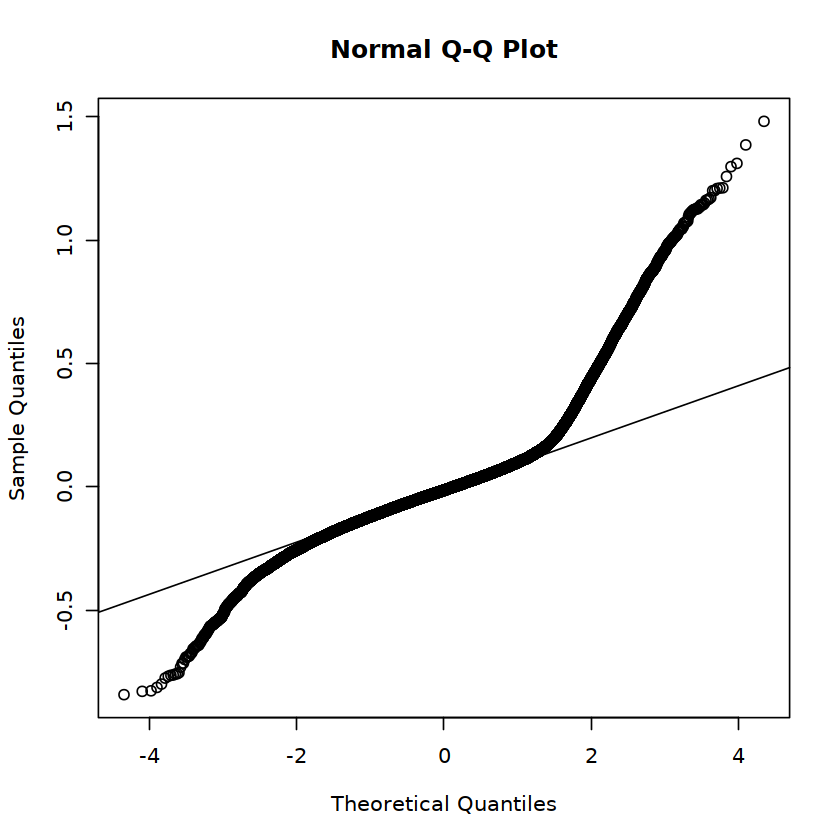

In [75]:
PCs <- paste0("PC",1:20, collapse = '+')
eq <- as.formula(paste0("HbA1c_M_residual ~ age + sex_age + age2 + sex_age2 + sex +", PCs))
fit <- lm(eq, data = dt)
residuals <- resid(fit)
qqnorm(residuals)
qqline(residuals)

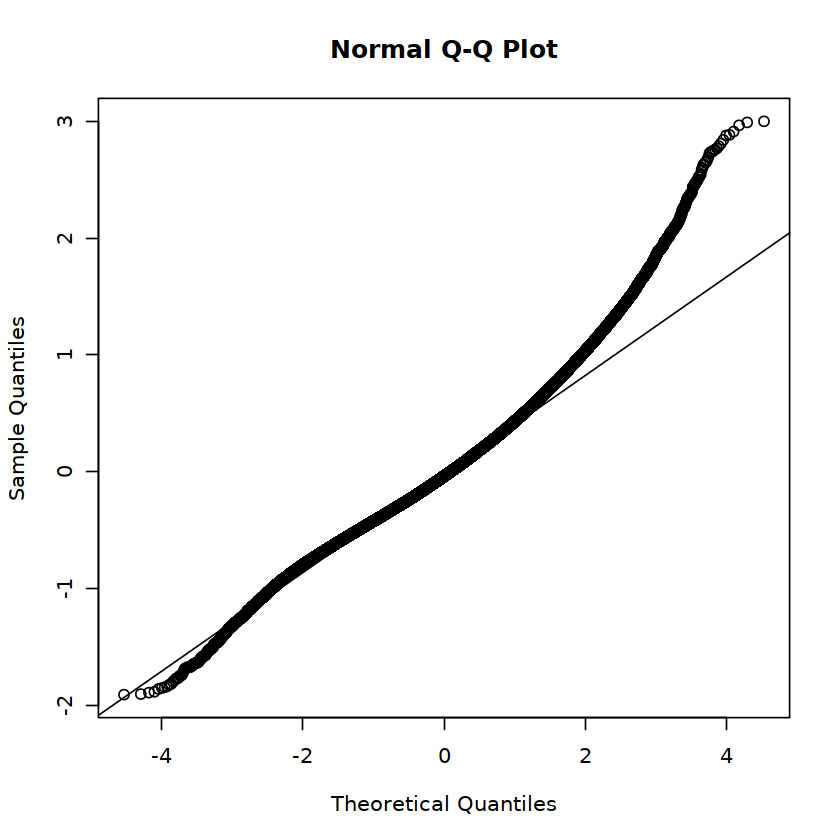

In [76]:
PCs <- paste0("PC",1:10, collapse = '+')
eq <- as.formula(paste0("Alanine_aminotransferase ~ age + age2 +", PCs))
fit <- lm(eq, data = dt)
residuals <- resid(fit)
qqnorm(residuals)
qqline(residuals)